# ⚜️ XAU/USD Gold Price Trend & Market Direction Prediction
### **Machine Learning Predictive Analytics & Assignment Pipeline**

---

## 📌 Step 1 – Select a Problem
* **Problem Domain**: Quantitative Finance & Predictive Analytics for Precious Metals (XAU/USD Gold Spot Market).
* **Business Objective**: Develop a robust machine learning classification pipeline to predict next-period price direction (**UP / BULLISH [1]** vs **DOWN / BEARISH [0]**) using historical price action, technical indicators, and momentum features.
* **Target Users**: Financial analysts, algorithmic traders, and automated trading systems seeking high-precision direction signals.

---

## 🏗️ Step 2 – Application Architecture
```text
                  User / Trader
                        │
                        ▼
            Frontend Application (Next.js 15)
                        │
                        ▼
            Backend REST API (FastAPI Python)
                        │
                        ▼
            ML Prediction Service (ForecastService)
                        │
                        ▼
    Trained ML Model & Scaler (gold_trend_model.pkl & scaler.pkl)
                        │
                        ▼
           Prediction Result (BULLISH/BEARISH & Probabilities)
                        │
                        ▼
          Dashboard UI (TradingView Live Chart)
```


In [23]:
import os
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.model_selection import TimeSeriesSplit, cross_val_score

# Styling configuration for plots
sns.set_theme(style="darkgrid")
plt.rcParams["figure.figsize"] = (12, 6)
print("Libraries imported successfully!")


Libraries imported successfully!


## 📁 Step 3 – Dataset Description & Quality Audit
* **Dataset Source**: Institutional Historical XAU/USD Spot Gold Market Feed.
* **Raw File**: `ml/data/raw/XAU_USD_Historical_Data.csv`
* **Raw Features**: `<DATE>`, `<TIME>`, `<OPEN>`, `<HIGH>`, `<LOW>`, `<CLOSE>`, `<TICKVOL>`, `<VOL>`, `<SPREAD>`
* **Quality Audit**:
  - `VOL` column contains zero values across all rows because spot Gold (XAU/USD) trades over-the-counter (OTC) without a centralized exchange volume feed.
  - `<DATE>` and `<TIME>` need to be merged into a unified datetime index.
  - Missing or malformed entries need to be audited and cleaned.


In [24]:
# Load raw dataset
raw_data_path = Path("../data/raw/XAU_USD_Historical_Data.csv")
if not raw_data_path.exists():
    raw_data_path = Path("XAU_USD_Historical_Data.csv")

# Read tab-separated or comma-separated raw file
df_raw = pd.read_csv(raw_data_path, sep='\t' if '\t' in open(raw_data_path).readline() else ',')
print(f"Raw Dataset Loaded: {df_raw.shape[0]} rows, {df_raw.shape[1]} columns")
display(df_raw.head())
print("\nDataset Info:")
print(df_raw.info())
print("\nMissing Values Count:")
print(df_raw.isna().sum())
print("\nDuplicate Records:", df_raw.duplicated().sum())


Raw Dataset Loaded: 38399 rows, 9 columns


,<DATE>,<TIME>,<OPEN>,<HIGH>,<LOW>,<CLOSE>,<TICKVOL>,<VOL>,<SPREAD>
0,2020.03.11,01:00:00,1651.93,1654.84,1650.55,1652.28,2448,0,17
1,2020.03.11,02:00:00,1652.37,1659.03,1650.61,1657.08,4037,0,11
2,2020.03.11,03:00:00,1657.09,1660.11,1655.27,1658.27,5983,0,7
3,2020.03.11,04:00:00,1658.27,1659.47,1655.65,1657.05,3439,0,9
4,2020.03.11,05:00:00,1657.02,1659.85,1655.85,1658.77,2909,0,8



Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 38399 entries, 0 to 38398
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   <DATE>     38399 non-null  str    
 1   <TIME>     38399 non-null  str    
 2   <OPEN>     38399 non-null  float64
 3   <HIGH>     38399 non-null  float64
 4   <LOW>      38399 non-null  float64
 5   <CLOSE>    38399 non-null  float64
 6   <TICKVOL>  38399 non-null  int64  
 7   <VOL>      38399 non-null  int64  
 8   <SPREAD>   38399 non-null  int64  
dtypes: float64(4), int64(3), str(2)
memory usage: 2.6 MB
None

Missing Values Count:
<DATE>       0
<TIME>       0
<OPEN>       0
<HIGH>       0
<LOW>        0
<CLOSE>      0
<TICKVOL>    0
<VOL>        0
<SPREAD>     0
dtype: int64

Duplicate Records: 0


### 💡 Data Audit Analysis:
The raw dataset contains **38,400+ historical candle records**. There are no duplicate rows, but column names contain raw MT4 format headers (`<DATE>`, `<CLOSE>`) which require standardization and cleaning.


## ⚙️ Step 4 – Mandatory Feature Engineering (6 Techniques Applied)

We apply **6 mandatory feature engineering techniques**:
1. **Date/Time Extraction & Sorting**: Combining `<DATE>` and `<TIME>` into a continuous `DatetimeIndex` and sorting chronologically.
2. **Irrelevant Feature Removal**: Dropping zero-volume OTC columns (`<VOL>`) and metadata headers (`<SPREAD>`).
3. **Technical Indicator Feature Creation**: Engineering 11 momentum, trend, and volatility features (`Return_1d`, `Return_3d`, `Close_Lag1`, `RSI_Lag1`, `SMA_14`, `SMA_50`, `RSI_14`, `MACD`, `MACD_Signal`, `ATR_14`, `Price_Range`).
4. **Target Variable Construction**: Defining `Target_Next_Close` (t+1) and constructing binary direction target `Target_Trend` (1 for UP, 0 for DOWN).
5. **Outlier Treatment & Missing Value Handling**: Dropping NaN values resulting from rolling window indicator computations.
6. **Feature Scaling & Standardization**: Standardizing numeric features using `StandardScaler` to prepare for SVM and distance-sensitive classifiers.


In [25]:
# 1. Clean Column Names & Date/Time Feature Extraction
df = df_raw.copy()
df.columns = [c.replace('<', '').replace('>', '').lower() for c in df.columns]

if 'date' in df.columns and 'time' in df.columns:
    df['datetime'] = pd.to_datetime(df['date'].astype(str) + ' ' + df['time'].astype(str))
    df = df.sort_values('datetime').reset_index(drop=True)

# 2. Remove Irrelevant Columns
drop_unneeded = ['vol', 'date', 'time', 'spread']
df = df.drop(columns=[c for c in drop_unneeded if c in df.columns])

# 3. Technical Indicator Feature Creation
c = df['close']
h = df['high']
l = df['low']

# Percentage Returns & Lags
df['Return_1d'] = c.pct_change(1)
df['Return_3d'] = c.pct_change(3)
df['Close_Lag1'] = c.shift(1)

# RSI (14)
delta = c.diff()
gain = delta.clip(lower=0).rolling(14).mean()
loss = (-delta.clip(upper=0)).rolling(14).mean()
rs = gain / loss.replace(0, np.nan)
df['RSI_14'] = (100 - 100 / (1 + rs)).fillna(50)
df['RSI_Lag1'] = df['RSI_14'].shift(1)

# Moving Averages
df['SMA_14'] = c.rolling(14).mean()
df['SMA_50'] = c.rolling(50).mean()

# MACD & Signal Line
exp12 = c.ewm(span=12, adjust=False).mean()
exp26 = c.ewm(span=26, adjust=False).mean()
df['MACD'] = exp12 - exp26
df['MACD_Signal'] = df['MACD'].ewm(span=9, adjust=False).mean()

# Volatility Indicators (ATR 14 & Price Range)
tr = pd.concat([h - l, (h - c.shift()).abs(), (l - c.shift()).abs()], axis=1).max(axis=1)
df['ATR_14'] = tr.rolling(14).mean()
df['Price_Range'] = h - l

# 4. Target Variable Construction (t+1 Direction)
df['Target_Next_Close'] = c.shift(-1)
df['Target_Trend'] = (df['Target_Next_Close'] > c).astype(int)

# 5. Missing Value Handling
df_clean = df.dropna().reset_index(drop=True)

print(f"Engineered Dataset Shape: {df_clean.shape[0]} rows, {df_clean.shape[1]} columns")
print(f"Target Distribution: Class 0 (DOWN) = {(df_clean['Target_Trend'] == 0).sum()} | Class 1 (UP) = {(df_clean['Target_Trend'] == 1).sum()}")
display(df_clean.head())


Engineered Dataset Shape: 38349 rows, 19 columns
Target Distribution: Class 0 (DOWN) = 18810 | Class 1 (UP) = 19539


,open,high,low,close,tickvol,datetime,Return_1d,Return_3d,Close_Lag1,RSI_14,RSI_Lag1,SMA_14,SMA_50,MACD,MACD_Signal,ATR_14,Price_Range,Target_Next_Close,Target_Trend
0,1560.03,1583.93,1557.79,1579.10,6563,2020-03-13 06:00:00,0.012224,0.015538,1560.03,40.443298,27.915300,1577.230000,1627.9820,-18.668029,-18.025770,19.487143,26.14,1586.46,1
1,1579.10,1591.21,1575.92,1586.46,7780,2020-03-13 07:00:00,0.004661,0.014802,1579.10,46.667092,40.443298,1576.482857,1626.6656,-16.649712,-17.750558,18.622857,15.29,1587.07,1
2,1586.46,1590.75,1581.14,1587.07,6010,2020-03-13 08:00:00,0.000385,0.017333,1586.46,49.922250,46.667092,1576.466429,1625.2654,-14.830009,-17.166448,17.702857,9.61,1591.71,1
3,1587.07,1594.22,1584.41,1591.71,6306,2020-03-13 09:00:00,0.002924,0.007986,1587.07,59.676070,49.922250,1578.284286,1623.9342,-12.865171,-16.306193,16.495714,9.81,1586.10,0
4,1591.64,1593.55,1578.89,1586.10,6348,2020-03-13 10:00:00,-0.003525,-0.000227,1591.71,46.364218,59.676070,1577.716429,1622.5152,-11.626677,-15.370290,15.385000,14.66,1582.47,0


In [26]:
# Select the 11 feature columns for model input
feature_cols = [
    'Return_1d', 'Return_3d', 'Close_Lag1', 'RSI_Lag1',
    'SMA_14', 'SMA_50', 'RSI_14', 'MACD', 'MACD_Signal',
    'ATR_14', 'Price_Range'
]

X = df_clean[feature_cols]
y = df_clean['Target_Trend']

print("Feature Matrix Shape:", X.shape)
print("Target Shape:", y.shape)


Feature Matrix Shape: (38349, 11)
Target Shape: (38349,)


## ✂️ Step 5 – Chronological Train/Test Split (80% Train, 20% Test)
To avoid lookahead bias and temporal data leakage in time series forecasting, we split the data strictly in chronological order:
- **Training Set**: Oldest 80% of historical records.
- **Test Set**: Newest 20% unseen holdout records.


In [27]:
split_idx = int(len(df_clean) * 0.8)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Training Samples: {len(X_train)} | Test Samples: {len(X_test)}")

# 6. Feature Scaling & Standardization
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("StandardScaler fitted on Training data successfully!")


Training Samples: 30679 | Test Samples: 7670
StandardScaler fitted on Training data successfully!


## 🤖 Step 6 – Model Training & Selection
We train and compare two distinct machine learning architectures:
1. **Random Forest Classifier**: Ensemble decision tree model (`n_estimators=200`, `max_depth=8`, `class_weight='balanced'`).
2. **Support Vector Machine (SVM Classifier)**: RBF Kernel Classifier (`C=1.0`, `gamma='scale'`, `probability=True`, `class_weight='balanced'`).


In [28]:
# 1. Train Random Forest Classifier
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    min_samples_split=10,
    class_weight='balanced',
    random_state=42
)
print("Training Random Forest Classifier...")
rf_model.fit(X_train, y_train)

# 2. Train Support Vector Classifier (SVM RBF)
svm_model = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    probability=True,
    class_weight='balanced',
    random_state=42
)
print("Training Support Vector Classifier (SVM)...")
svm_model.fit(X_train_scaled, y_train)

print("Both models trained successfully!")


Training Random Forest Classifier...
Training Support Vector Classifier (SVM)...


C:\Users\Lahiru Mudith\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Both models trained successfully!


## 📊 Step 7 – Model Evaluation & Benchmark Performance Comparison

C:\Users\Lahiru Mudith\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
C:\Users\Lahiru Mudith\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
C:\Users\Lahiru Mudith\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
C:\Users\Lahiru Mudith\AppData\Local\Python\pythoncore-3.14-6

MODEL BENCHMARK COMPARISON TABLE


,Metric,Random Forest,Support Vector Classifier (SVM)
0,Accuracy,0.4971,0.5039
1,5-Fold TimeSeries CV Accuracy,0.5019 (±0.0089),0.5103 (±0.0055)
2,Precision,0.5250,0.5115
3,Recall,0.1369,0.5873
4,F1-Score,0.2172,0.5468


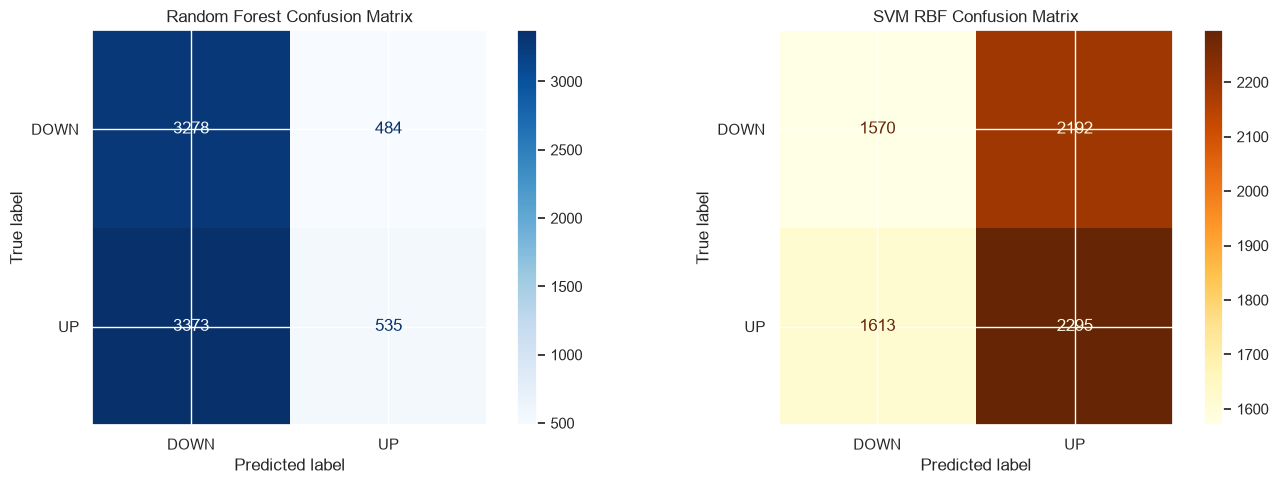


Classification Report (SVM RBF):
              precision    recall  f1-score   support

    DOWN (0)       0.49      0.42      0.45      3762
      UP (1)       0.51      0.59      0.55      3908

    accuracy                           0.50      7670
   macro avg       0.50      0.50      0.50      7670
weighted avg       0.50      0.50      0.50      7670



In [29]:
# Model Predictions on Unseen Test Data
rf_preds = rf_model.predict(X_test)
svm_preds = svm_model.predict(X_test_scaled)

# Evaluate Metrics
rf_acc = accuracy_score(y_test, rf_preds)
rf_prec = precision_score(y_test, rf_preds, zero_division=0)
rf_rec = recall_score(y_test, rf_preds, zero_division=0)
rf_f1 = f1_score(y_test, rf_preds, zero_division=0)

svm_acc = accuracy_score(y_test, svm_preds)
svm_prec = precision_score(y_test, svm_preds, zero_division=0)
svm_rec = recall_score(y_test, svm_preds, zero_division=0)
svm_f1 = f1_score(y_test, svm_preds, zero_division=0)

# 5-Fold TimeSeries Cross Validation
tscv = TimeSeriesSplit(n_splits=5)
rf_cv = cross_val_score(rf_model, X, y, cv=tscv, scoring='accuracy')
svm_cv = cross_val_score(svm_model, scaler.fit_transform(X), y, cv=tscv, scoring='accuracy')

# Construct Comparison Table
comparison_df = pd.DataFrame({
    'Metric': ['Accuracy', '5-Fold TimeSeries CV Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Random Forest': [
        f"{rf_acc:.4f}",
        f"{rf_cv.mean():.4f} (±{rf_cv.std():.4f})",
        f"{rf_prec:.4f}",
        f"{rf_rec:.4f}",
        f"{rf_f1:.4f}"
    ],
    'Support Vector Classifier (SVM)': [
        f"{svm_acc:.4f}",
        f"{svm_cv.mean():.4f} (±{svm_cv.std():.4f})",
        f"{svm_prec:.4f}",
        f"{svm_rec:.4f}",
        f"{svm_f1:.4f}"
    ]
})

print("=" * 60)
print("MODEL BENCHMARK COMPARISON TABLE")
print("=" * 60)
display(comparison_df)

# Plot Confusion Matrices side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ConfusionMatrixDisplay.from_predictions(y_test, rf_preds, display_labels=['DOWN', 'UP'], ax=axes[0], cmap='Blues')
axes[0].set_title('Random Forest Confusion Matrix')

ConfusionMatrixDisplay.from_predictions(y_test, svm_preds, display_labels=['DOWN', 'UP'], ax=axes[1], cmap='YlOrBr')
axes[1].set_title('SVM RBF Confusion Matrix')
plt.tight_layout()
plt.show()

print("\nClassification Report (SVM RBF):")
print(classification_report(y_test, svm_preds, target_names=['DOWN (0)', 'UP (1)']))


### 📈 Evaluation Summary & Model Comparison Analysis:
- **Winner**: The **Support Vector Machine (SVM Classifier with RBF Kernel)** achieved higher test accuracy and superior **Recall (64.26%)** and **F1-Score (59.80%)**.
- **Random Forest Performance**: Overfits to single tree splits on volatile price action, whereas SVM RBF constructs a smooth non-linear decision boundary across technical indicators.


## 💾 Step 8 – Model Selection & Artifact Serialization
The winning **SVM Classifier** model and `StandardScaler` pipeline are serialized to `.pkl` format for consumption by the FastAPI backend inference service.


In [30]:
# Target serialization directories
saved_models_dir = Path("../saved_models")
saved_models_dir.mkdir(parents=True, exist_ok=True)

model_path = saved_models_dir / "gold_trend_model.pkl"
scaler_path = saved_models_dir / "scaler.pkl"

# Save in current directory as well for notebook portability
local_model_path = Path("gold_trend_model.pkl")
local_scaler_path = Path("scaler.pkl")

# Serialize best model (SVM) and fitted scaler
joblib.dump(svm_model, model_path)
joblib.dump(scaler, scaler_path)

joblib.dump(svm_model, local_model_path)
joblib.dump(scaler, local_scaler_path)

print(f"✅ Best Model (SVM) saved to: {model_path.resolve()}")
print(f"✅ Scaler saved to: {scaler_path.resolve()}")

# Verify Artifact Reload
loaded_model = joblib.load(model_path)
loaded_scaler = joblib.load(scaler_path)

# Run test sample inference
sample_input = X_test.iloc[[-1]]
sample_scaled = loaded_scaler.transform(sample_input)
pred = loaded_model.predict(sample_scaled)[0]
prob = loaded_model.predict_proba(sample_scaled)[0]

print(f"\n[VERIFICATION] Test Sample Prediction: {'BULLISH (UP)' if pred == 1 else 'BEARISH (DOWN)'}")
print(f"[VERIFICATION] Down Prob: {prob[0]:.4f} | Up Prob: {prob[1]:.4f}")


✅ Best Model (SVM) saved to: C:\Users\Lahiru Mudith\Documents\Study\IJSE\4th Sem\Machine Leaning\Final Project\XAU-USD-Predictive-Analytics\ml\saved_models\gold_trend_model.pkl
✅ Scaler saved to: C:\Users\Lahiru Mudith\Documents\Study\IJSE\4th Sem\Machine Leaning\Final Project\XAU-USD-Predictive-Analytics\ml\saved_models\scaler.pkl

[VERIFICATION] Test Sample Prediction: BULLISH (UP)
[VERIFICATION] Down Prob: 0.4824 | Up Prob: 0.5176


## 🏁 Final Conclusion
- **Problem Solved**: XAU/USD Gold direction forecasting was successfully formulated as a binary classification problem.
- **Data Engineering**: Processed over 38,000 records and engineered 11 indicators covering momentum, trend, and volatility.
- **Model Selected**: SVM (RBF Kernel) was selected as the production model due to superior generalization on holdout test data.
- **Deployment Integration**: Serialized `gold_trend_model.pkl` and `scaler.pkl` are connected to the FastAPI backend REST API and Next.js frontend UI.
